# Global Mean Sea Level from Altimetry
Ruth Moorman (adapted by Olivia Alcabes) April 21 (for Andy Thompson ESE144 lecture)

In [18]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import pandas as pd


<div class="alert alert-block alert-info">
<b>DATA ACCESS:</b>
<div> 
<div>        
In this notebook, all data was obtained from JPL's <b>Physical Oceanography Distributed Active Archive Center (PODAAC)</b>, one of the many directories out there where you can search and access satellite data. PODAAC is part of the NASA EARTHDATA system which houses numerous DAACs of various science themes.
<div><div>

If you do not have a login to NASA Earthdata login, get one! We won't necessarily need it in class (exept potentially for your final project) but it's a great resource. Instructions are [here](https://www.earthdata.nasa.gov/eosdis/science-system-description/eosdis-components/earthdata-login).




## Level 4 Timeseries Data


The first data product we'll use is a proprocessed multi-satellite Level 4 product showing Global Mean Sea Level (GSML) that I accessed [here](https://podaac.jpl.nasa.gov/dataset/MERGED_TP_J1_OSTM_OST_GMSL_ASCII_V51#). This product was generated and released as part of the Making Earth Science Data Records for Use in Research Environments (MEaSUREs) program.


In [ ]:
## load data

file_path = '../online_data/GMSL_TPJAOS_5.2.txt'

df = pd.read_csv(
    file_path, 
    skiprows=50, 
    header=None, 
    sep='\s+',
    names=[
        'altimeter_type', 'cycle', 'year_fraction', 'obs', 'weighted_obs',
        'gmsl_no_gia', 'std_dev_no_gia', 'smoothed_no_gia',
        'gmsl_gia', 'std_dev_gia', 'smoothed_gia',
        'gmsl_smoothed_removed', 'gmsl_no_gia_smoothed_removed'
    ]
)

df = df.replace(99900.000, float('nan'))
df = df.set_index('year_fraction')

preprocessed_GMSL = df.to_xarray()
preprocessed_GMSL

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/var/folders/61/g7zmhtnn1d711pqwkv1nq_jm0000gn/T/ipykernel_80772/1812782933.py:9: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


<xarray.Dataset> Size: 124kB
Dimensions:                       (year_fraction: 1193)
Coordinates:
  * year_fraction                 (year_fraction) float64 10kB nan ... 2.025e+03
Data variables:
    altimeter_type                (year_fraction) object 10kB 'HDR' ... '0'
    cycle                         (year_fraction) object 10kB nan ... '1202'
    obs                           (year_fraction) float64 10kB nan ... 4.673e+05
    weighted_obs                  (year_fraction) float64 10kB nan ... 3.366e+05
    gmsl_no_gia                   (year_fraction) float64 10kB nan nan ... 59.46
    std_dev_no_gia                (year_fraction) float64 10kB nan nan ... 89.34
    smoothed_no_gia               (year_fraction) float64 10kB nan nan ... 58.35
    gmsl_gia                      (year_fraction) float64 10kB nan nan ... 67.35
    std_dev_gia                   (year_fraction) float64 10kB nan nan ... 88.84
    smoothed_gia                  (year_fraction) float64 10kB nan nan ... 66.23
    gmsl_smoothed_removed         (year_fraction) float64 10kB nan nan ... 70.3
    gmsl_no_gia_smoothed_removed  (year_fraction) float64 10kB nan nan ... 62.43

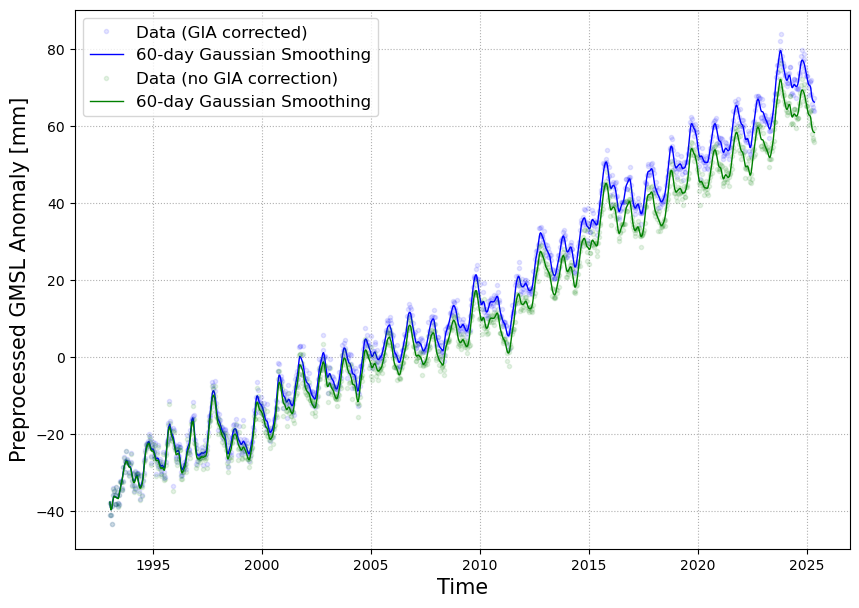

In [15]:
fig,ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(preprocessed_GMSL.year_fraction, preprocessed_GMSL.gmsl_gia, 'bo', markersize=3,alpha=0.1, label='Data (GIA corrected)')
ax.plot(preprocessed_GMSL.year_fraction, preprocessed_GMSL.smoothed_gia, 'b-', linewidth=1, label='60-day Gaussian Smoothing')
ax.plot(preprocessed_GMSL.year_fraction, preprocessed_GMSL.gmsl_no_gia, 'go', markersize=3,alpha=0.1, label='Data (no GIA correction)')
ax.plot(preprocessed_GMSL.year_fraction, preprocessed_GMSL.smoothed_no_gia, 'g-', linewidth=1, label='60-day Gaussian Smoothing')
ax.legend(loc=0, fontsize=12)
ax.set_ylabel('Preprocessed GMSL Anomaly [mm]', fontsize=15)
ax.set_xlabel('Time', fontsize=15)
ax.grid(linestyle=':')
plt.show()


<div class="alert alert-block alert-info">
<b>TASK:</b>
<div>
Use the numpy function [np.polyfit](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) to compute linear and quadratic fits to the available GMSL rise data (both for the GIA corrected and non GIA corrected data). Plot these functions alongside the timeseries data below. 
   

Note: you will need to use the year fraction dimension `preprocessed_GMSL.year_fraction` to compute fits (np.datetime[64]).


In [ ]:
## compute linear and quadratic fits... ##

x = preprocessed_GMSL.year_fraction[2:] # remove the first two data points bc they're NaN
y_gia = preprocessed_GMSL.gmsl_gia[2:]

## use np.polyfit to compute linear (deg=1) and quadratic (deg=2) fits
### your code ###
lin_fit_gia = ##
quad_fit_gia = ##

SyntaxError: invalid syntax (396617351.py, line 8)

NameError: name 'x' is not defined

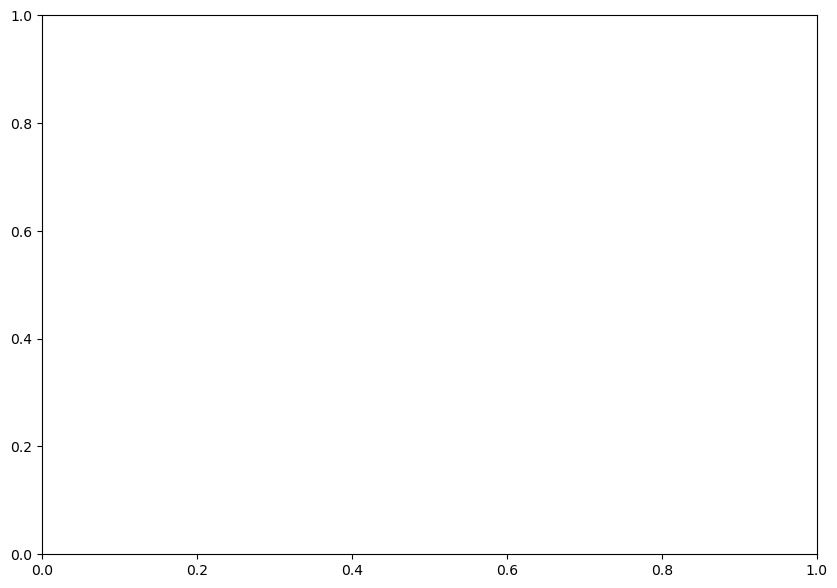

In [ ]:
fig,ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(x, preprocessed_GMSL.gmsl_gia, 'bo', markersize=3,alpha=0.1, label='Data (GIA corrected)')


#### include linear and quadratic fits ####
### your code ###
rang = np.arange(1993.011526, 2024.124418, .001) # Something relevant for you
plt.plot(rang, np.polyval(lin_fit_gia, rang))
plt.plot(rang, np.polyval(quad_fit_gia, rang))


ax.legend(loc=0, fontsize=12)
ax.set_ylabel('Preprocessed GMSL Anomaly [mm]', fontsize=15)
ax.set_xlabel('Time', fontsize=15)
ax.grid(linestyle=':')
plt.show()


<div class="alert alert-block alert-info">
<b>TASK:</b>
<div>
Print your fits and interpret the linear rate of change of sea-level over the satellite era, and it's potential acceleration.



<div class="alert alert-block alert-info">
<b>DISCUSS:</b>
<div>
What methods are available to us to try and determine whether sea level rise has truly accelerated over the satellite era?




<div class="alert alert-block alert-info">
<b>DISCUSS:</b>
<div>
Glacial Isostatic Adjustement (GIA) is a process by which the Earth's mantle moves and crust deforms in response to the removal of large ice sheets since the last ice age. Areas where the crust was pushed down by ice sheets previously are now rebounding (rising upwards), with halos present around these regions where the crust is deprepressing as mantle material flows into the ice sheet region from surrounding areas. 
    <div>

What is the effect of the GIA correction and what does this indicate abount the mean effect of GIA over the oceans? Check out <a href="https://grace.jpl.nasa.gov/internal_resources/134/">this map of modeled GIA trends</a> to confirm.

